# Notebook 02: Dimensionality Reduction and Modelling

This notebook covers PCA and t-SNE for dimensionality reduction and visualisation, followed by training three classifiers using scikit-learn pipelines with hyperparameter tuning.

## Setup

We load the preprocessed splits saved by Notebook 01 — `X_train.csv`, `X_test.csv`,
`y_train.csv`, `y_test.csv`, and `feature_names.csv`. These splits were created with
a stratified 80/20 split and already have one-hot encoded features.

**Important:** we do not load the raw CSV here. All preprocessing (encoding, imputation,
leakage removal) was done in Notebook 01 and the results were saved to `data/`.
Loading the raw data again and re-doing those steps would risk introducing subtle
inconsistencies.

In [ ]:
import os
import sys
sys.path.append('..')    # so we can import from src/ and utils.py at the repo root

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
os.makedirs('../figures', exist_ok=True)

RANDOM_STATE = 42

# ── Load preprocessed splits ────────────────────────────────────
X_train = pd.read_csv('../data/X_train.csv')
X_test  = pd.read_csv('../data/X_test.csv')
y_train = pd.read_csv('../data/y_train.csv').squeeze()  # squeeze turns 1-col DataFrame -> Series
y_test  = pd.read_csv('../data/y_test.csv').squeeze()
feature_names = pd.read_csv('../data/feature_names.csv').squeeze().tolist()

print(f'X_train: {X_train.shape}  |  X_test: {X_test.shape}')
print(f'y_train positive rate: {y_train.mean():.2%}')
print(f'y_test  positive rate: {y_test.mean():.2%}')
print(f'Number of features: {len(feature_names)}')

X_train: (36168, 40)  |  X_test: (9043, 40)
y_train positive rate: 11.70%
y_test  positive rate: 11.70%
Number of features: 40


## Scaling

PCA is sensitive to the scale of features — a feature with a range of 0–100,000
(like `balance`) would dominate the variance calculation over a binary 0/1 feature.
We fit a `StandardScaler` **on the training set only** and apply it to both sets.

Fitting the scaler on both train and test together would leak information about the
test set mean and standard deviation into the training process — exactly the same
kind of leakage that justified dropping `duration` in Notebook 01.
Here we avoid it by keeping the scaler fit strictly inside the training data.

In [ ]:
# Fit scaler on training data ONLY — never fit on test data.
# Applying the training-set scaler to the test set is correct:
# the test set should be transformed using the same mean/std the model was trained with.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)       # transform only, not fit

print(f'Scaled X_train — mean: {X_train_scaled.mean():.4f}  std: {X_train_scaled.std():.4f}')
print(f'Scaled X_test  — mean: {X_test_scaled.mean():.4f}  std: {X_test_scaled.std():.4f}')
# The test mean/std will not be exactly 0/1 because the scaler was fitted on the training set.

Scaled X_train — mean: 0.0000  std: 1.0000
Scaled X_test  — mean: 0.0009  std: 0.9939


## PCA — Principal Component Analysis

PCA finds the directions (principal components) that capture the most variance in the data.
We run it with `n_components=None` first, which computes *all* components and lets us
inspect how the variance is distributed across them before deciding how many to keep.

Three plots follow:
1. **Scree plot** — variance explained by each component individually.
2. **Cumulative variance** — how many components are needed to explain 95 % of the variance.
3. **2D scatter (PC1 vs PC2)** — whether the two classes are linearly separable
   in the first two principal components.

In [ ]:
# n_components=None means compute all components (= number of features = 40).
# We will decide how many to keep after looking at the scree and cumulative variance plots.
pca_full = PCA(n_components=None, random_state=RANDOM_STATE)
pca_full.fit(X_train_scaled)

evr = pca_full.explained_variance_ratio_          # fraction of variance per component
cumulative_evr = np.cumsum(evr)

n_components_95 = np.argmax(cumulative_evr >= 0.95) + 1   # +1 because argmax returns 0-indexed
print(f'Components needed to reach 95% variance: {n_components_95}')
print(f'Variance explained by PC1: {evr[0]:.2%}')
print(f'Variance explained by PC2: {evr[1]:.2%}')

Components needed to reach 95% variance: 31
Variance explained by PC1: 9.62%
Variance explained by PC2: 6.76%


### Scree plot — variance per component

The scree plot shows how much of the total variance each individual component explains.
We plot the first 20 components; after that the contribution of each additional component
is very small. The 'elbow' in the curve suggests a natural cutoff point.

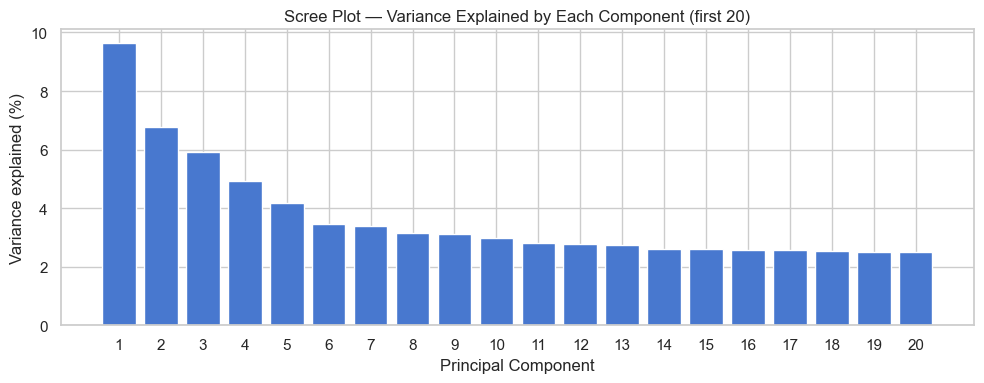

In [ ]:
n_show = 20   # show only the first 20 components — the rest contribute very little

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(1, n_show + 1), evr[:n_show] * 100,
       color='#4878CF', edgecolor='white')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Variance explained (%)')
ax.set_title('Scree Plot — Variance Explained by Each Component (first 20)')
ax.set_xticks(range(1, n_show + 1))

plt.tight_layout()
plt.savefig('../figures/06_pca_scree.png', dpi=150, bbox_inches='tight')
plt.show()

### Cumulative explained variance

This plot answers the practical question: *how many components do I need to keep?*
The dashed horizontal line marks 95 % — a common threshold that retains most information
while discarding the remaining noise components.

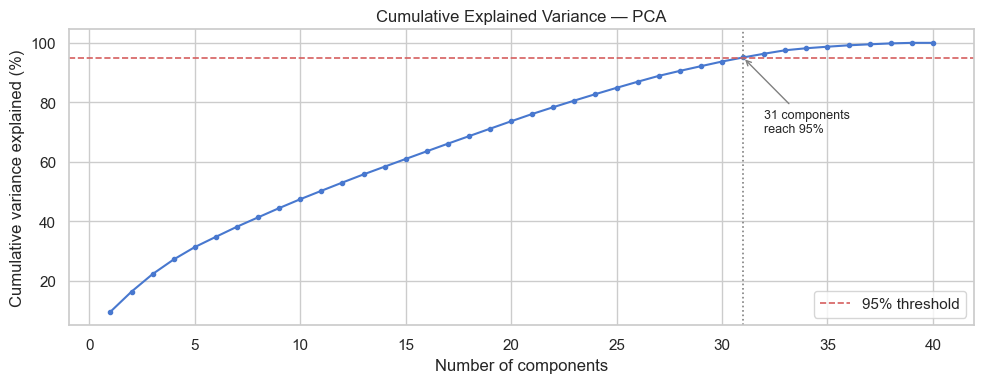

We choose 31 components to retain at least 95% of variance.


In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(1, len(cumulative_evr) + 1), cumulative_evr * 100,
        marker='o', markersize=3, linewidth=1.5, color='#4878CF')

# Dashed reference line at 95%
ax.axhline(95, color='#D65F5F', linestyle='--', linewidth=1.2, label='95% threshold')

# Vertical marker at the component that first crosses 95%
ax.axvline(n_components_95, color='grey', linestyle=':', linewidth=1.2)
ax.annotate(
    f'{n_components_95} components\nreach 95%',
    xy=(n_components_95, cumulative_evr[n_components_95 - 1] * 100),
    xytext=(n_components_95 + 1, 70),
    arrowprops={'arrowstyle': '->', 'color': 'grey'},
    fontsize=9,
)
ax.set_xlabel('Number of components')
ax.set_ylabel('Cumulative variance explained (%)')
ax.set_title('Cumulative Explained Variance — PCA')
ax.legend()

plt.tight_layout()
plt.savefig('../figures/07_pca_cumulative_variance.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'We choose {n_components_95} components to retain at least 95% of variance.')